In [34]:
import tensorflow as tf
from tensorflow.keras import datasets,layers,models
import matplotlib.pyplot as plt
import numpy as np
import numpy as np
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
import seaborn as sns
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize


In [2]:
(X_train,y_train),(X_test,y_test)=datasets.cifar10.load_data()
X_train.shape

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


(50000, 32, 32, 3)

In [3]:
y_train = y_train.reshape(-1,) # flatten the array
y_train[:5]

array([6, 9, 9, 4, 1], dtype=uint8)

In [4]:
classes=["airplane","automobile","bird","cat","deer","dog","frog","horse","ship","truck"]

In [5]:

X_test = X_test/255
X_train = X_train/255

In [7]:
cnn =models.Sequential([
    #cnn
    layers.Conv2D(filters=32,kernel_size=(3,3),activation='relu',input_shape=(32,32,3)),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(filters=32,kernel_size=(3,3),activation='relu',input_shape=(32,32,3)),
    layers.MaxPooling2D((2,2)),
    #dense
    layers.Flatten(),
    layers.Dense(64,activation='relu'),
    layers.Dense(10,activation='softmax')
])


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [11]:
cnn.compile(optimizer='adam',
            loss='sparse_categorical_crossentropy',
            metrics=['accuracy'])

In [12]:
cnn.fit(X_train,y_train,epochs=10)

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 50s 31ms/step - accuracy: 0.3504 - loss: 1.7590
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 80s 30ms/step - accuracy: 0.5626 - loss: 1.2370
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 81s 29ms/step - accuracy: 0.6175 - loss: 1.0961
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 81s 29ms/step - accuracy: 0.6511 - loss: 0.9985
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 81s 28ms/step - accuracy: 0.6758 - loss: 0.9307
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 46s 29ms/step - accuracy: 0.6907 - loss: 0.8846
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 80s 28ms/step - accuracy: 0.7163 - loss: 0.8292
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 45s 29ms/step - accuracy: 0.7227 - loss: 0.7967
Epoch 9/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 82s 28ms/step - accuracy: 0.7320 - loss: 0.7687
Epoch 10/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 82s 29ms/step - accuracy: 0.7477 - loss: 0.7265


In [13]:
cnn.evaluate(X_test,y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.6788 - loss: 0.9348


[0.9458414912223816, 0.6735000014305115]

In [14]:
y_test

array([[3],
       [8],
       [8],
       ...,
       [5],
       [1],
       [7]], dtype=uint8)

In [15]:
y_test= y_test.reshape(-1,)
y_test[:5]


array([3, 8, 8, 0, 6], dtype=uint8)

In [17]:
def plot_sample(X,y,index):
    plt.figure(figsize=(15,2))
    plt.imshow(X[index])
    plt.xlabel(classes[y[index]])

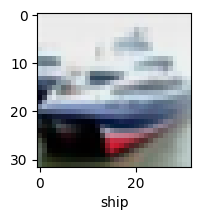

In [18]:
plot_sample(X_test,y_test,1)


In [20]:
y_pred=cnn.predict(X_test)
y_pred[:5]

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step


array([[8.4866828e-04, 4.7860780e-05, 6.9601014e-03, 9.2368174e-01,
        8.5486408e-04, 5.3703871e-02, 1.2649619e-02, 7.7773337e-05,
        1.0786103e-03, 9.6880714e-05],
       [3.3246335e-03, 1.1554688e-02, 1.9129425e-06, 2.9346052e-07,
        2.5862013e-07, 3.4226833e-08, 4.0549974e-08, 8.7940271e-07,
        9.8484975e-01, 2.6749374e-04],
       [2.3020780e-02, 6.7530937e-02, 2.9764805e-04, 2.1815537e-03,
        6.3721061e-04, 1.3497579e-04, 2.5697483e-04, 5.0456042e-04,
        9.0072215e-01, 4.7131716e-03],
       [8.5584426e-01, 1.5623457e-02, 1.9034229e-02, 8.8078534e-04,
        8.0904029e-03, 6.7981440e-05, 1.3496689e-04, 1.7751227e-05,
        1.0027536e-01, 3.0689713e-05],
       [2.3653711e-06, 1.4753023e-05, 1.3783833e-02, 4.6847567e-02,
        6.0487336e-01, 2.2812467e-03, 3.3214208e-01, 2.3042345e-05,
        3.1558080e-05, 1.1813452e-07]], dtype=float32)

In [21]:
y_calsses=[np.argmax(element) for element in y_pred]
y_calsses[:5]

[3, 8, 8, 0, 4]

In [22]:
y_test[:5]

array([3, 8, 8, 0, 6], dtype=uint8)

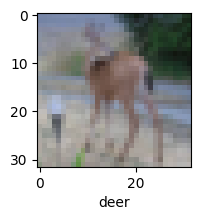

In [24]:
plot_sample(X_test,y_test,100)

In [25]:
classes[y_calsses[100]]

'deer'

In [28]:
print("classification report:\n",classification_report(y_test,y_calsses))

classification report:
               precision    recall  f1-score   support

           0       0.77      0.65      0.70      1000
           1       0.89      0.70      0.78      1000
           2       0.61      0.53      0.57      1000
           3       0.50      0.50      0.50      1000
           4       0.56      0.71      0.63      1000
           5       0.64      0.50      0.56      1000
           6       0.69      0.81      0.74      1000
           7       0.72      0.72      0.72      1000
           8       0.66      0.87      0.75      1000
           9       0.77      0.76      0.76      1000

    accuracy                           0.67     10000
   macro avg       0.68      0.67      0.67     10000
weighted avg       0.68      0.67      0.67     10000



In [30]:
cm = confusion_matrix(y_test, y_calsses)

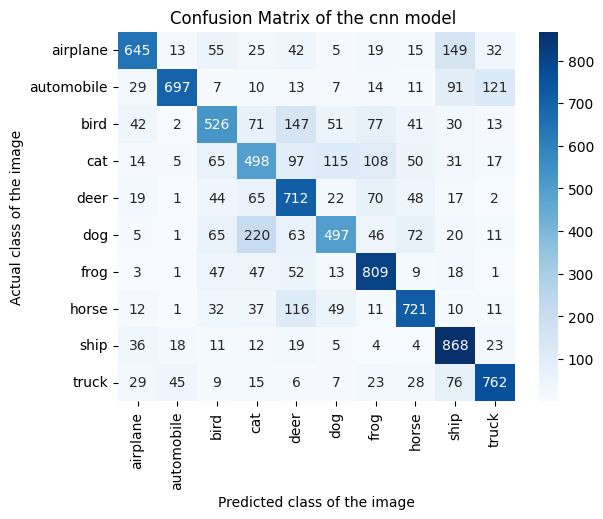

In [33]:
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes, yticklabels=classes)
plt.xlabel('Predicted class of the image')
plt.ylabel('Actual class of the image')
plt.title('Confusion Matrix of the cnn model ')
plt.show()

In [35]:
y_test_binary = label_binarize(y_test, classes=np.unique(y_test))
y_pred_binary = label_binarize(y_calsses, classes=np.unique(y_test))
n_classes = y_test_binary.shape[1]

In [38]:
FPR = dict()
TPR = dict()
ROC_AUC_curve = dict()
for i in range(n_classes):
   FPR["micro"], TPR["micro"], _ = roc_curve(y_test_binary.ravel(), y_pred_binary.ravel())
ROC_AUC_curve["micro"] = auc(FPR["micro"], TPR["micro"])

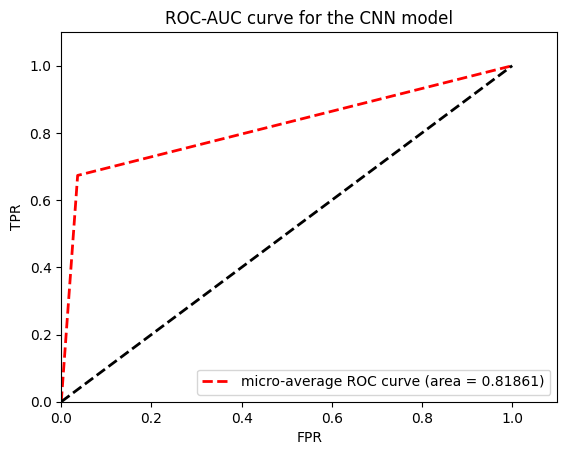

In [41]:
plt.figure()
plt.plot(
    FPR["micro"],
    TPR["micro"],
    label="micro-average ROC curve (area = {0:0.5f})".format(ROC_AUC_curve["micro"]),
    color="red",
    linestyle="--",
    linewidth=2,
)

plt.plot([0, 1], [0, 1], "k--", lw=2)
plt.xlim([0.0, 1.10])
plt.ylim([0.0, 1.10])
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC-AUC curve for the CNN model")
plt.legend(loc="lower right")
plt.show()